<a href="https://colab.research.google.com/github/rmhanna/Randa/blob/main/WaterLevelsPlot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAI614: Data Science & its Applications

*Notebook 7.1: Introducing Dask*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%207/Notebook7.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Source: NVIDIA

# Dask

Dask is not faster than pandas for a single file or for small size data.  It excels for multiple data as it uses lazy computaion. In this lab, we will learn how to use Dask to speed up computation under the correct conditions.

First, let's get these libraries loaded.

In [ ]:
!pip install dask

import dask.dataframe as dd
import glob
import pandas as pd
import time
import urllib
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

## Using Dask versus Pandas

Neither pandas or cuDF can read in multiple CSV files directly with [read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). In order to read multiple files into a DataFrame, we would need to loop through each file and append them together.

To see this, let's pull a couple more files from the [Water Level Website](https://tidesandcurrents.noaa.gov/stations.html?type=Water+Levels). This time, we will request a CSV and save it with the [urllib.request](https://docs.python.org/3/library/urllib.request.html).

In [ ]:
import dask.dataframe as dd

# Load the /content/waterlevel.csv file with Dask
ddf_waterlevel = dd.read_csv('/content/waterlevel.csv', dtype={'Preliminary (ft)': 'object'})

# Display the head to see the loaded data
ddf_waterlevel.head()

,Date,Time (GMT),Predicted (ft),Preliminary (ft),Verified (ft)
0,2025/12/15,00:00,0.902,0.48,-
1,2025/12/15,00:06,0.904,0.47,-
2,2025/12/15,00:12,0.906,0.46,-
3,2025/12/15,00:18,0.908,0.44,-
4,2025/12/15,00:24,0.909,0.46,-


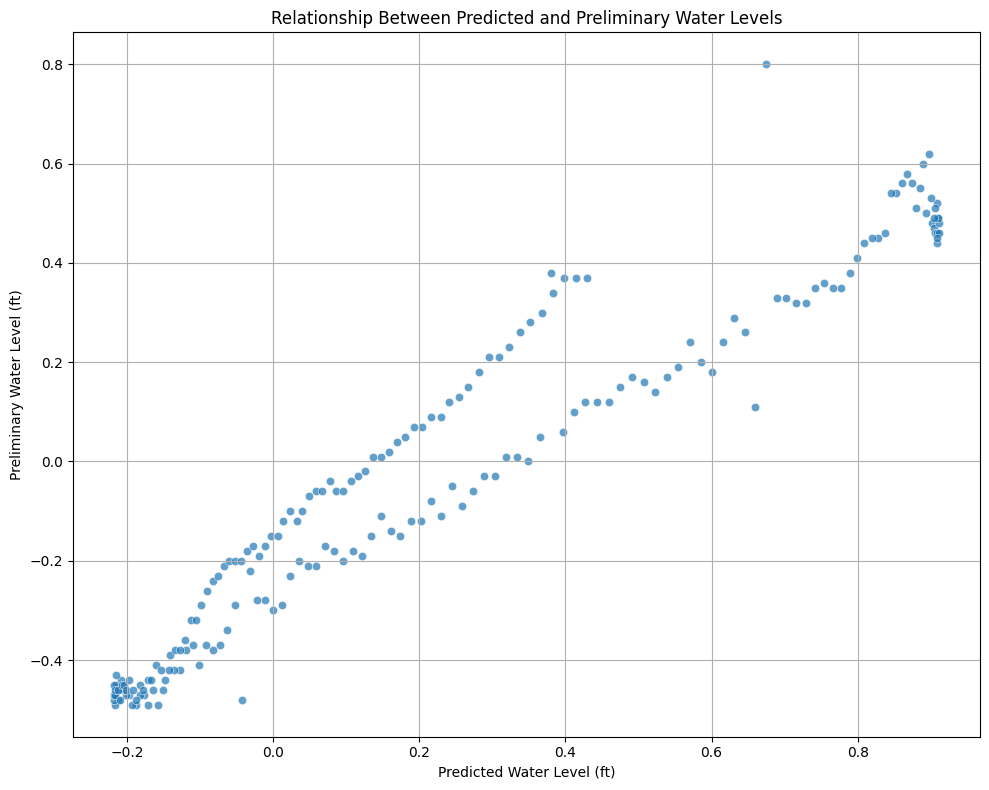

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Predicted (ft)', y='Preliminary (ft)', data=plot_df, alpha=0.7)

plt.title('Relationship Between Predicted and Preliminary Water Levels')
plt.xlabel('Predicted Water Level (ft)')
plt.ylabel('Preliminary Water Level (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

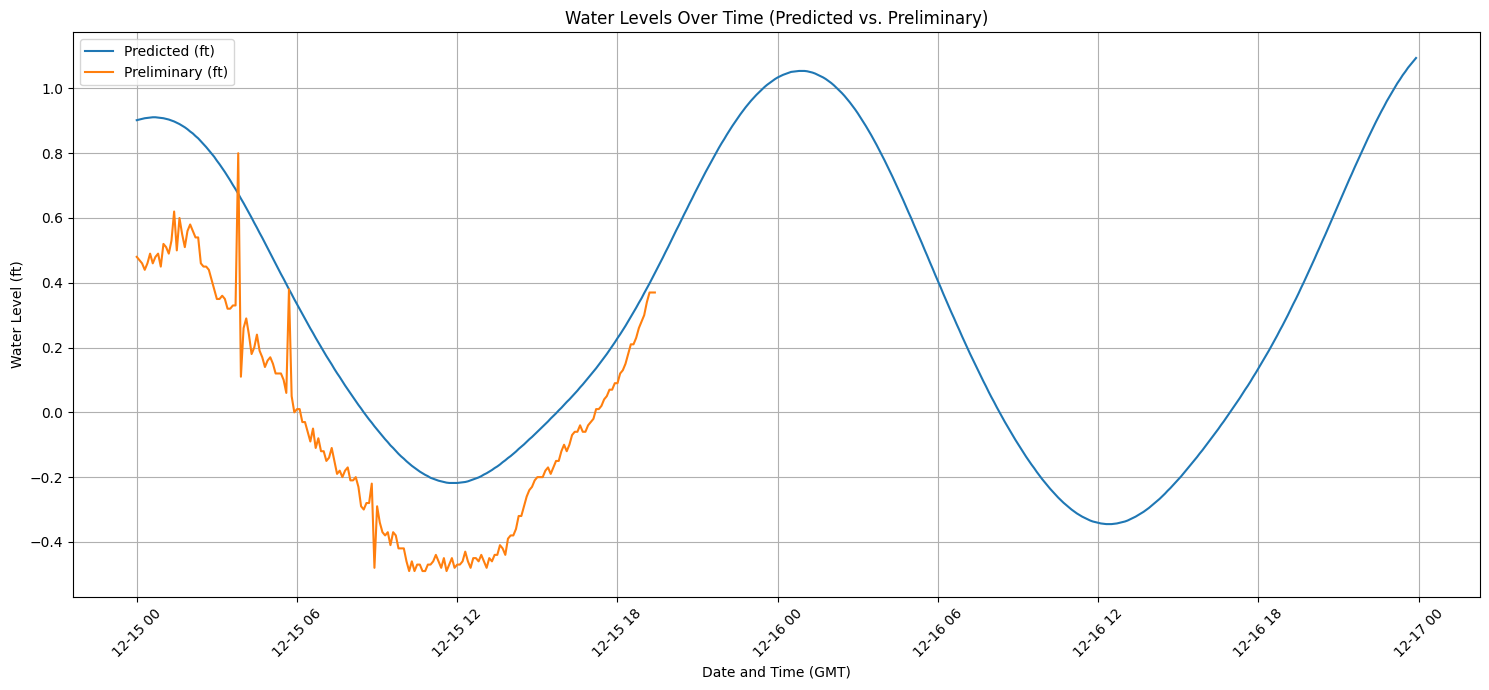

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert 'Date Time (GMT)' to datetime objects in Dask
# Combine Date and Time (GMT) columns first if they are separate
ddf_waterlevel['datetime'] = ddf_waterlevel['Date'] + ' ' + ddf_waterlevel['Time (GMT)']
ddf_waterlevel['datetime'] = ddf_waterlevel['datetime'].apply(lambda x: pd.to_datetime(x, format='%Y/%m/%d %H:%M'), meta=('datetime', 'datetime64[ns]'))

# Select the columns for plotting and convert to pandas for plotting
# For larger datasets, one might sample or aggregate before collecting to pandas
plot_df = ddf_waterlevel[['datetime', 'Predicted (ft)', 'Preliminary (ft)']].compute()

# Create the plot
plt.figure(figsize=(15, 7))
sns.lineplot(x='datetime', y='Predicted (ft)', data=plot_df, label='Predicted (ft)')
sns.lineplot(x='datetime', y='Preliminary (ft)', data=plot_df, label='Preliminary (ft)')

plt.title('Water Levels Over Time (Predicted vs. Preliminary)')
plt.xlabel('Date and Time (GMT)')
plt.ylabel('Water Level (ft)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Convert 'Preliminary (ft)' to numeric, coercing errors to NaN
ddf_waterlevel['Preliminary (ft)'] = ddf_waterlevel['Preliminary (ft)'].apply(
    pd.to_numeric, errors='coerce', meta=('Preliminary (ft)', 'float64')
)

# Display the head to see the updated data
ddf_waterlevel.head()

,Date,Time (GMT),Predicted (ft),Preliminary (ft),Verified (ft)
0,2025/12/15,00:00,0.902,0.48,-
1,2025/12/15,00:06,0.904,0.47,-
2,2025/12/15,00:12,0.906,0.46,-
3,2025/12/15,00:18,0.908,0.44,-
4,2025/12/15,00:24,0.909,0.46,-


In [ ]:
# Display the updated data types
ddf_waterlevel.dtypes

,0
Date,string[pyarrow]
Time (GMT),string[pyarrow]
Predicted (ft),float64
Preliminary (ft),float64
Verified (ft),string[pyarrow]


In [ ]:
# Calculate the number of missing values in 'Verified (ft)'
missing_count = ddf_waterlevel['Verified (ft)'].isnull().sum().compute()
print(f"Number of missing values in 'Verified (ft)': {missing_count}")

# Calculate the percentage of missing values in 'Verified (ft)'
total_rows = ddf_waterlevel.shape[0].compute() # Corrected to use .shape[0].compute()
missing_percentage = (missing_count / total_rows) * 100
print(f"Percentage of missing values in 'Verified (ft)': {missing_percentage:.2f}%")

Number of missing values in 'Verified (ft)': 0
Percentage of missing values in 'Verified (ft)': 0.00%


In [ ]:
ddf_waterlevel.dtypes

,0
Date,string[pyarrow]
Time (GMT),string[pyarrow]
Predicted (ft),float64
Preliminary (ft),float64
Verified (ft),string[pyarrow]


We should now have a few `.csv` files in the `data` folder. When referencing these files, we could type out the paths of each of these files individually, but instead, we will use the [glob](https://docs.python.org/3/library/glob.html) library to programmatically do this for us. We can use `*` as a wild card to filter files that match our pattern specified like so:

### `ddf_waterlevel` Data Types

In [ ]:
ddf_waterlevel.dtypes

,0
Date,string[pyarrow]
Time (GMT),string[pyarrow]
Predicted (ft),float64
Preliminary (ft),float64
Verified (ft),string[pyarrow]


### `ddf_waterlevel` Descriptive Statistics

In [ ]:
ddf_waterlevel.describe().compute()

,Predicted (ft),Preliminary (ft)
count,480.000000,195.000000
mean,0.323754,-0.033744
std,0.453432,0.342602
min,-0.345000,-0.490000
25%,-0.099750,-0.370000
50%,0.267500,-0.070000
75%,0.767500,0.250000
max,1.094000,0.800000


In [ ]:
file_paths = glob.glob("data/*.csv")
file_paths = [file for file in file_paths if file != "data/numbers.csv"]
file_paths

['data/synthetic_data_3.csv',
 'data/synthetic_data_2.csv',
 'data/synthetic_data_0.csv',
 'data/synthetic_data_4.csv',
 'data/synthetic_data_1.csv']

Each path starts with `data`, ends with `.csv`, and the `*` indicates to pick up anything in between. Let's set up a for loop to see how long it takes to read all of these files. Run the block **twice** to see how much faster cuDF is after it has been initialized.

In [ ]:
usecols = [0, 1, 2, 4, 5]  # Column names are different when pulling csv directly

def read_all(library, file_paths):
    df_list = []
    for file in file_paths:
        df = library.read_csv(
            file, index_col=None, header=None, usecols=usecols, skiprows=1
        )
        df_list.append(df)
    return library.concat(df_list, axis=0, ignore_index=True)

df_cpu = read_all(pd, file_paths)

In [ ]:
import os
import pandas as pd
import numpy as np

# Create 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

# Generate 5 synthetic CSV files
num_files = 5
num_rows_per_file = 1000
num_columns = 6 # Changed to 6 columns to satisfy usecols=[0,1,2,4,5]

for i in range(num_files):
    filename = os.path.join('data', f'synthetic_data_{i}.csv')
    # Create a DataFrame with 6 columns
    df = pd.DataFrame(np.random.rand(num_rows_per_file, num_columns), columns=[f'col_{j}' for j in range(num_columns)])
    df.to_csv(filename, index=False, header=False) # Write without header or index
    print(f"Generated: {filename}")

print("Finished generating synthetic files.")

Generated: data/synthetic_data_0.csv
Generated: data/synthetic_data_1.csv
Generated: data/synthetic_data_2.csv
Generated: data/synthetic_data_3.csv
Generated: data/synthetic_data_4.csv
Finished generating synthetic files.


In [ ]:
df_cpu

,0,1,2,4,5
0,0.595051,0.921402,0.126096,0.747808,0.831753
1,0.497643,0.081765,0.624636,0.396811,0.666250
2,0.040394,0.493884,0.988489,0.922145,0.584234
3,0.729772,0.196680,0.721178,0.113710,0.209782
4,0.578687,0.403442,0.118699,0.929512,0.598753
...,...,...,...,...,...
4990,0.260167,0.826271,0.011835,0.518730,0.585185
4991,0.273820,0.798918,0.879203,0.450100,0.377094
4992,0.657054,0.842355,0.733748,0.438263,0.387335
4993,0.321970,0.272769,0.185968,0.129621,0.713480


Since Dask is made to be parallel, we do not need a for loop. It can read multiple files natively.

The below code shows how to read data in parallel. This only sets up the process to read the files. we need to force Dask to *compute*

In [ ]:
ddf_cpu = dd.read_csv(file_paths, usecols=usecols, header=0, skipinitialspace=True)

ddf_cpu.compute()

,0.20009783384080915,0.8428018639823934,0.24646175324048258,0.9958537605410155,0.12111414771445006,0.6522886510779056,0.7981235287659113,0.601927735484454,0.3519423809068406,0.29530171041811737,...,0.16111153794898414,0.9920919589224604,0.8852751071024949,0.5623754033273062,0.5990285580590995,0.8801289947312023,0.138015694968058,0.7093001468204773,0.7108614798991502,0.46904558014109365
0,0.600342,0.336562,0.364675,0.955078,0.222180,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.696334,0.819310,0.893142,0.827157,0.124913,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.694594,0.783465,0.357342,0.901393,0.096363,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.641560,0.062019,0.423395,0.777881,0.506224,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.915960,0.391939,0.732593,0.577897,0.072450,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.572885,0.395276,0.032308,0.249461,0.990697
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.266137,0.498324,0.671244,0.701897,0.998780
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.552138,0.779627,0.354235,0.476565,0.132305
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.565835,0.481637,0.609993,0.456606,0.723875


Let's sample our data to confirm it had been read correctly. This time, we will only be working with the first three columns of data.

In [ ]:
%%time
ddf_cpu.head()

CPU times: user 11.8 ms, sys: 1.87 ms, total: 13.6 ms
Wall time: 17.9 ms


,0.20009783384080915,0.8428018639823934,0.24646175324048258,0.9958537605410155,0.12111414771445006
0,0.600342,0.336562,0.364675,0.955078,0.222180
1,0.696334,0.819310,0.893142,0.827157,0.124913
2,0.694594,0.783465,0.357342,0.901393,0.096363
3,0.641560,0.062019,0.423395,0.777881,0.506224
4,0.915960,0.391939,0.732593,0.577897,0.072450


How can Dask do this faster than regular pandas or cuDF? Under the hood, Dask is building a system of operations called a DAG. We can view this DAG with the [visualize](https://docs.dask.org/en/latest/graphviz.html) method.

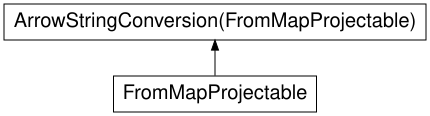

In [ ]:
ddf_cpu.visualize()

### Pandas DataFrame: `df_cpu.mean()`

In [ ]:
%%time
df_cpu.mean()

CPU times: user 1.63 ms, sys: 0 ns, total: 1.63 ms
Wall time: 2.21 ms


,0
0,0.499702
1,0.502973
2,0.503640
4,0.496954
5,0.495541


### Dask DataFrame: `ddf_cpu.mean().compute()`

In [ ]:
%%time
ddf_cpu.mean().compute()

CPU times: user 58.9 ms, sys: 5.96 ms, total: 64.9 ms
Wall time: 81.9 ms


,0
0.20009783384080915,0.499119
0.8428018639823934,0.513680
0.24646175324048258,0.499131
0.9958537605410155,0.502545
0.12111414771445006,0.493423
0.6522886510779056,0.514650
0.7981235287659113,0.497760
0.601927735484454,0.497246
0.3519423809068406,0.500903
0.29530171041811737,0.503656
